In [25]:
# Imports

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score,
	precision_score,
	recall_score,
    brier_score_loss,
	confusion_matrix,
    roc_curve,
    precision_recall_curve
)

In [26]:
def compute_metrics(df, threshold=0.7):

    y = df.y_true.values
    p = df.p_pred.values

    y_pred = (p > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

    return {
        "roc_auc": roc_auc_score(y, p),
        "roc": roc_curve(y, p),

        "pr_auc": average_precision_score(y, p),
        "pr": precision_recall_curve(y, p),
        
        "f1": f1_score(y, y_pred),
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "brier": brier_score_loss(y, p),
        "confusion": {
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp)
        },
        "n": len(df)
    }

In [27]:
def confusion_matrix_dataframe(cm):

    return pd.DataFrame(
        [
            [cm["TN"], cm["FP"]],
            [cm["FN"], cm["TP"]],
        ],
        index=["Actual Negative", "Actual Positive"],
        columns=["Predicted Negative", "Predicted Positive"]
    )

In [28]:
def metrics_for(experiment_id=None):
	if experiment_id:
		filename = f"results.{experiment_id}"
	else:
		filename = "results"

	results = json.load(open(f"./data/{filename}.json"))
	df = pd.DataFrame(results)

	metrics = {}

	metrics["overall"] = compute_metrics(df)

	for doc_type in df.doc_type.unique():
		metrics[doc_type] = compute_metrics(df[df.doc_type == doc_type])

	return metrics, df

In [29]:
# Load metrics

#experiment_id = "baseline_sentence_nli_r1"
#experiment_id = "baseline_sentence_nli_r2"
#experiment_id = "cluster_sentence_nli_r1"
#experiment_id = "cluster_claims_nli_r1"
experiment_id = "cluster_claims_nli_r2"

metrics, df = metrics_for(experiment_id)

In [30]:
output_folder = f"data/{experiment_id}/"
if not os.path.isdir(output_folder):
	os.makedirs(output_folder)

In [31]:
# Results overview table

table = pd.DataFrame(metrics).T

table.drop(columns=['confusion', 'roc', 'pr'], inplace=True)

table = table.astype({ 'n': int })

latex = table.to_latex(
    float_format="%.3f",
    caption="Contradiction detection performance",
    label="tab:results",

)

with open(f"{output_folder}/results.tex", "w") as f:
    f.write(latex)

print(latex)

table

\begin{table}
\caption{Contradiction detection performance}
\label{tab:results}
\begin{tabular}{llllllllr}
\toprule
 & roc_auc & pr_auc & f1 & accuracy & precision & recall & brier & n \\
\midrule
overall & 0.578 & 0.572 & 0.576 & 0.548 & 0.546 & 0.609 & 0.331 & 882 \\
news & 0.611 & 0.597 & 0.449 & 0.535 & 0.562 & 0.373 & 0.275 & 312 \\
story & 0.571 & 0.574 & 0.610 & 0.518 & 0.510 & 0.759 & 0.387 & 284 \\
wiki & 0.597 & 0.584 & 0.642 & 0.591 & 0.580 & 0.719 & 0.337 & 286 \\
\bottomrule
\end{tabular}
\end{table}



,roc_auc,pr_auc,f1,accuracy,precision,recall,brier,n
overall,0.577631,0.571617,0.575983,0.547619,0.546371,0.608989,0.331291,882
news,0.611047,0.596909,0.448669,0.535256,0.561905,0.373418,0.275097,312
story,0.570674,0.573541,0.609687,0.517606,0.509524,0.758865,0.386877,284
wiki,0.597334,0.584121,0.642202,0.590909,0.58011,0.719178,0.337396,286


In [32]:
# Confusion matrix table per doc type

for doc_type in metrics.keys():
    cm_df = confusion_matrix_dataframe(metrics[doc_type]['confusion'])
    latex = cm_df.to_latex(
        caption=f"Confusion matrix for contradiction detection ({doc_type})",
        label="tab:confusion_matrix"
    )

    with open(f"{output_folder}/cm_{doc_type}.tex", "w") as f:
        f.write(latex)

    print(latex)
    print()

\begin{table}
\caption{Confusion matrix for contradiction detection (overall)}
\label{tab:confusion_matrix}
\begin{tabular}{lrr}
\toprule
 & Predicted Negative & Predicted Positive \\
\midrule
Actual Negative & 212 & 225 \\
Actual Positive & 174 & 271 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}
\caption{Confusion matrix for contradiction detection (news)}
\label{tab:confusion_matrix}
\begin{tabular}{lrr}
\toprule
 & Predicted Negative & Predicted Positive \\
\midrule
Actual Negative & 108 & 46 \\
Actual Positive & 99 & 59 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}
\caption{Confusion matrix for contradiction detection (story)}
\label{tab:confusion_matrix}
\begin{tabular}{lrr}
\toprule
 & Predicted Negative & Predicted Positive \\
\midrule
Actual Negative & 40 & 103 \\
Actual Positive & 34 & 107 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}
\caption{Confusion matrix for contradiction detection (wiki)}
\label{tab:confusion_matrix}
\begin{tabular}{lrr}

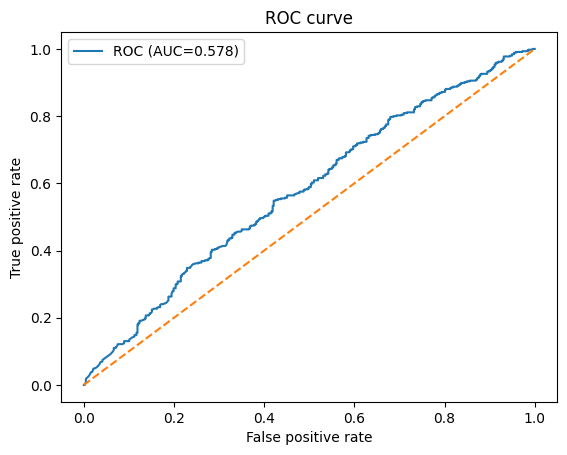

In [33]:
# ROC curve

fpr, tpr, _ = metrics["overall"]["roc"]

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC={metrics['overall']['roc_auc']:.3})")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.legend()

plt.savefig(f"{output_folder}/roc.jpg")

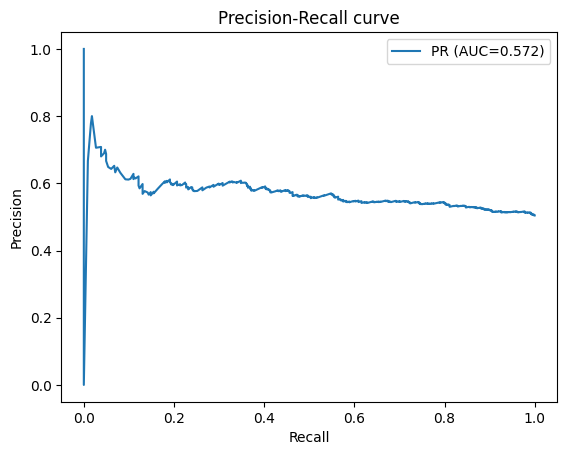

In [34]:
# Precision-Recall curve

prec, rec, _ = metrics['overall']['pr']

plt.figure()
plt.plot(rec, prec, label=f"PR (AUC={metrics['overall']['pr_auc']:.3})")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.legend()

plt.savefig(f"{output_folder}/pr.jpg")

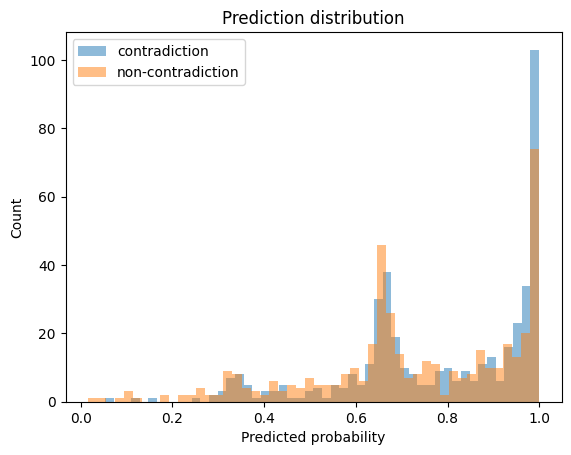

In [35]:
# Prediction distribution histogram

plt.figure()

plt.hist(df[df.y_true==1].p_pred, bins=50, alpha=0.5, label="contradiction")
plt.hist(df[df.y_true==0].p_pred, bins=50, alpha=0.5, label="non-contradiction")

plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Prediction distribution")
plt.legend()

plt.savefig(f"{output_folder}/histogram.jpg")

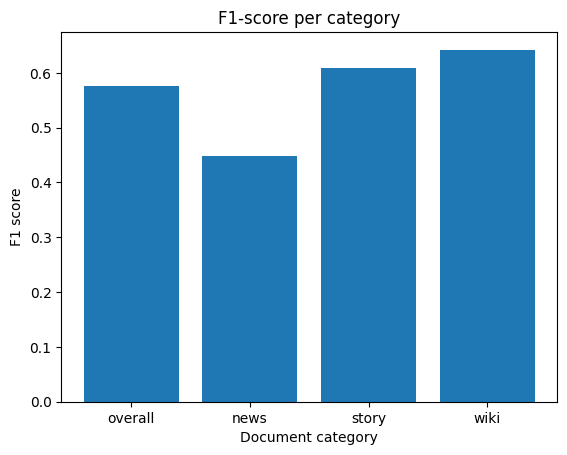

In [36]:
# F1 per category graph

cats = list(metrics.keys())
f1_scores = [metrics[c]["f1"] for c in cats]

plt.figure()
plt.bar(cats, f1_scores)
plt.ylabel("F1 score")
plt.xlabel("Document category")
plt.title("F1-score per category")

plt.savefig(f"{output_folder}/categories.jpg")